# DINO Family Searchlight RSA: DINOv1 and DINOv2

**Pipeline:**
1. Load IAPS images (60 stimuli, converted to grayscale)
2. Extract image embeddings (CLS token) from DINOv1 and DINOv2
3. Build model RDMs from each set of embeddings
4. Run whole-brain searchlight RSA (20 subjects)
5. Group-level t-maps at FDR 0.05, 0.01, 0.001

Both DINO models are purely self-supervised (no text, no emotion labels).
This tests whether emotion-free visual structure representations
can explain neural patterns in affective scene processing.

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import torch
from PIL import Image
from glob import glob
from torchvision import transforms
from sklearn.metrics import pairwise_distances
from tqdm import tqdm
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from scipy.stats import ttest_1samp, spearmanr
from statsmodels.stats.multitest import fdrcorrection
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from rsatoolbox.util.searchlight import evaluate_models_searchlight
from rsatoolbox.model import ModelFixed
from rsatoolbox.inference import eval_fixed

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

os.makedirs('./outputs/tBrainmap', exist_ok=True)
os.makedirs('./outputs/embeddings', exist_ok=True)

Device: cpu


In [2]:
# =====================================================================
# CONFIG
# =====================================================================

# Directory containing the 60 IAPS images
IAPS_IMAGE_DIR = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\data\raw_iaps"
# ^^^ UPDATE if your images are elsewhere

# IAPS image order file (determines row order in the RDM)
IAPS_ORDER_CSV = r"..\IAPS_Searchlight\IAPS_60_pnu.csv"

# fMRI searchlight data
FMRI_DATA_DIR = r"."
TMP_IMG_PATH  = os.path.join(FMRI_DATA_DIR, 'tmp.img')
MASK_PATH     = os.path.join(FMRI_DATA_DIR, 'mask.npy')
ALLSUB_PATH   = os.path.join(FMRI_DATA_DIR, 'allsub_avg.npy')

# Searchlight parameters
SL_RADIUS    = 5
SL_THRESHOLD = 0.5
N_JOBS       = 6

# Statistics
FDR_ALPHAS        = [0.05, 0.01, 0.001]
CLUSTER_THRESHOLD = 30

N_STIMULI = 60

In [3]:
def upper_tri(RDM):
    """Extract upper triangle of a square RDM (excluding diagonal)."""
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]


def rdm_from_features(features, metric='correlation'):
    """Build an RDM from a feature matrix (n_stimuli x n_features)."""
    rdm = pairwise_distances(features, metric=metric)
    np.fill_diagonal(rdm, 0)
    return rdm


def normalize_rdm(rdm):
    """Min-max normalize an RDM to [0, 1]."""
    mn, mx = rdm.min(), rdm.max()
    if mx - mn == 0:
        return rdm
    return (rdm - mn) / (mx - mn)

## 1. Load IAPS images in stimulus order

In [4]:
# Load IAPS ordering
iaps_order = pd.read_csv(IAPS_ORDER_CSV)
iaps_ids = [str(x) for x in iaps_order['iaps_id']]
print(f'IAPS order: {len(iaps_ids)} images')
print(f'First 5: {iaps_ids[:5]}')

# Find image files and load in order
all_files = glob(os.path.join(IAPS_IMAGE_DIR, '*'))
# Build lookup: strip extension, map to full path
file_lookup = {}
for f in all_files:
    base = os.path.splitext(os.path.basename(f))[0]
    file_lookup[base] = f

images_pil = []
for iid in iaps_ids:
    if iid in file_lookup:
        img = Image.open(file_lookup[iid]).convert('L').convert('RGB')  # grayscale -> 3ch
        images_pil.append(img)
    else:
        raise FileNotFoundError(f'Image not found for IAPS ID: {iid}')

print(f'Loaded {len(images_pil)} images')
print(f'Sample size: {images_pil[0].size}')

IAPS order: 60 images
First 5: ['4680', '4641', '8250', '8186', '4626']
Loaded 60 images
Sample size: (1024, 768)


## 2. Extract embeddings from DINOv1 and DINOv2

For each model we extract the CLS token (global image representation).
Both use torch.hub, no HuggingFace authentication needed.

In [5]:
# Shared preprocessing: ImageNet normalization, 224x224
dino_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [6]:
# =====================================================================
# DINOv1 (ViT-B/16) via torch.hub
# =====================================================================
print('Loading DINOv1 ViT-B/16...')
dinov1 = torch.hub.load('facebookresearch/dino:main', 'dino_vitb16')
dinov1.eval().to(device)

dinov1_embeddings = []
with torch.no_grad():
    for img in tqdm(images_pil, desc='DINOv1'):
        x = dino_transform(img).unsqueeze(0).to(device)
        cls_token = dinov1(x)  # DINOv1 forward returns CLS token directly
        dinov1_embeddings.append(cls_token.cpu().numpy().flatten())

dinov1_embeddings = np.array(dinov1_embeddings)
print(f'DINOv1 embeddings: {dinov1_embeddings.shape}')  # (60, 768)

del dinov1
torch.cuda.empty_cache() if device == 'cuda' else None

Loading DINOv1 ViT-B/16...


Using cache found in C:\Users\yujunchen/.cache\torch\hub\facebookresearch_dino_main
DINOv1: 100%|██████████| 60/60 [00:04<00:00, 13.99it/s]

DINOv1 embeddings: (60, 768)


In [7]:
# =====================================================================
# DINOv2 (ViT-B/14) via torch.hub
# =====================================================================
print('Loading DINOv2 ViT-B/14...')
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2.eval().to(device)

dinov2_embeddings = []
with torch.no_grad():
    for img in tqdm(images_pil, desc='DINOv2'):
        x = dino_transform(img).unsqueeze(0).to(device)
        cls_token = dinov2(x)  # DINOv2 forward returns CLS token directly
        dinov2_embeddings.append(cls_token.cpu().numpy().flatten())

dinov2_embeddings = np.array(dinov2_embeddings)
print(f'DINOv2 embeddings: {dinov2_embeddings.shape}')  # (60, 768)

del dinov2
torch.cuda.empty_cache() if device == 'cuda' else None

Loading DINOv2 ViT-B/14...


Using cache found in C:\Users\yujunchen/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\yujunchen/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\yujunchen/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\yujunchen/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
DINOv2: 100%|██████████| 60/60 [00:04<00:00, 12.21it/s]

DINOv2 embeddings: (60, 768)


In [8]:
# Save all embeddings
all_embeddings = {
    'DINOv1_vitb16': dinov1_embeddings,
    'DINOv2_vitb14': dinov2_embeddings,
}

for name, emb in all_embeddings.items():
    np.save(f'./outputs/embeddings/{name}_embeddings.npy', emb)
    print(f'Saved: {name}_embeddings.npy  shape={emb.shape}')

Saved: DINOv1_vitb16_embeddings.npy  shape=(60, 768)
Saved: DINOv2_vitb14_embeddings.npy  shape=(60, 768)


## 3. Build RDMs and compare across models

In [9]:
rdms = {}
for name, emb in all_embeddings.items():
    rdm = rdm_from_features(emb, metric='correlation')
    rdms[name] = rdm
    print(f'{name} RDM: {rdm.shape}, range [{rdm.min():.4f}, {rdm.max():.4f}]')

# Cross-model RDM correlation
model_names = list(rdms.keys())
r, p = spearmanr(upper_tri(rdms[model_names[0]]),
                 upper_tri(rdms[model_names[1]]))
print(f'\nDINOv1 vs DINOv2 RDM correlation: r = {r:.3f}  (p = {p:.2e})')

DINOv1_vitb16 RDM: (60, 60), range [0.0000, 1.0873]
DINOv2_vitb14 RDM: (60, 60), range [0.0000, 1.1035]

DINOv1 vs DINOv2 RDM correlation: r = 0.568  (p = 5.87e-152)


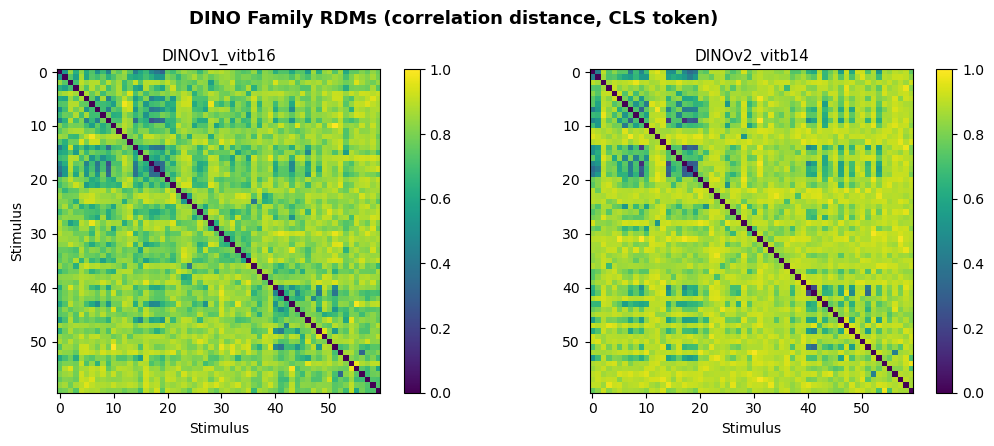

In [10]:
# Visualize RDMs
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, rdm) in zip(axes, rdms.items()):
    im = ax.imshow(normalize_rdm(rdm), cmap='viridis', aspect='equal')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Stimulus')
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[0].set_ylabel('Stimulus')
plt.suptitle('DINO Family RDMs (correlation distance, CLS token)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/DINO_family_RDMs.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Save RDMs
for name, rdm in rdms.items():
    pd.DataFrame(rdm, index=iaps_ids, columns=iaps_ids).to_csv(
        f'./outputs/rdm_{name}.csv')
    print(f'Saved: rdm_{name}.csv')

Saved: rdm_DINOv1_vitb16.csv
Saved: rdm_DINOv2_vitb14.csv


## 4. Load fMRI data and build searchlight

In [12]:
tmp_img = nib.load(TMP_IMG_PATH)
mask = np.load(MASK_PATH)
allsub_avg = np.load(ALLSUB_PATH, allow_pickle=True)
centers, neighbors = get_volume_searchlight(mask, radius=SL_RADIUS, threshold=SL_THRESHOLD)

print(f'Mask shape: {mask.shape}')
print(f'Subject data shape: {allsub_avg.shape}')
print(f'Searchlight centers: {len(centers)}')

Finding searchlights...: 100%|██████████| 59159/59159 [00:07<00:00, 8160.84it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Subject data shape: (20, 60, 153594)
Searchlight centers: 56949


## 5. Searchlight RSA functions

In [13]:
def run_searchlight_for_model(model_name, model_rdm, allsub_avg, centers, neighbors, mask):
    """
    Run searchlight RSA for a single model RDM across all subjects.
    Returns eval_score_list (n_subjects, n_centers) and voxel_indices.
    """
    model_obj = ModelFixed(model_name, upper_tri(model_rdm))

    eval_score_list = []
    RDM_brain_list = []
    x, y, z = mask.shape

    for i in tqdm(range(allsub_avg.shape[0]), desc=f'{model_name}'):
        subj_data = np.nan_to_num(allsub_avg[i])
        image_value = np.arange(subj_data.shape[0])

        SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')

        eval_results = evaluate_models_searchlight(SL_RDM, model_obj, eval_fixed, method='spearman', n_jobs=N_JOBS)
        eval_score = [float(e.evaluations) for e in eval_results]

        RDM_brain = np.zeros(x * y * z)
        RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
        RDM_brain = RDM_brain.reshape(x, y, z)

        eval_score_list.append(eval_score)
        RDM_brain_list.append(RDM_brain)

    voxel_indices = np.array(SL_RDM.rdm_descriptors['voxel_index'])
    return np.array(eval_score_list), RDM_brain_list, voxel_indices


def compute_tmap_from_scores(eval_scores, voxel_indices, mask_shape, tmp_img,
                             fdr_alpha=0.001, cluster_threshold=30,
                             model_name='', t_value_threshold=None):
    """
    Fisher z-transform -> one-sample t-test -> FDR correction
    -> optional t threshold -> 3D t-map -> cluster threshold.
    """
    epsilon = 1e-10
    scores_clipped = np.clip(eval_scores, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(scores_clipped)

    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0, nan_policy='omit')

    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig_mask = rejected

    if t_value_threshold is not None:
        sig_mask = sig_mask & (t_stats >= t_value_threshold)
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha} AND t >= {t_value_threshold})")
    else:
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha})")

    sig_voxels = np.where(sig_mask)[0]

    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)

    t_map_3d[t_map_3d < 0] = np.nan

    t_img = new_img_like(tmp_img, t_map_3d)

    t_img_cluster = nlimg.threshold_img(
        t_img,
        threshold=0,
        cluster_threshold=cluster_threshold
    )

    return t_img_cluster, t_stats, p_fdr

## 6. Run searchlight RSA for DINOv1 and DINOv2

In [14]:
results = {}

for model_name, model_rdm in rdms.items():
    print(f"\n{'='*60}")
    print(f"  Running searchlight for: {model_name}")
    print(f"{'='*60}")

    eval_scores, rdm_brains, voxel_ids = run_searchlight_for_model(
        model_name, model_rdm, allsub_avg, centers, neighbors, mask
    )

    # Save per-subject eval scores
    pd.DataFrame(eval_scores).to_csv(f'./outputs/20sub_SL_eval_{model_name}.csv')
    np.save(f'./outputs/20sub_SL_eval_{model_name}.npy', eval_scores)
    print(f'Saved. Shape: {eval_scores.shape}')

    results[model_name] = {
        'eval_scores': eval_scores,
        'voxel_ids': voxel_ids,
    }


  Running searchlight for: DINOv1_vitb16


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:16<00:00, 3352.41it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_35784\2134652681.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
DINOv1_vitb16: 100%|██████████| 20/20 [21:33<00:00, 64.68s/it]


Saved. Shape: (20, 56949)

  Running searchlight for: DINOv2_vitb14


DINOv2_vitb14: 100%|██████████| 20/20 [22:06<00:00, 66.32s/it]


Saved. Shape: (20, 56949)


## 7. Group statistics and t-maps (FDR 0.05, 0.01, 0.001)

In [15]:
tmaps = {}  # {model_name: {fdr_alpha: tmap_img}}

for model_name, res in results.items():
    tmaps[model_name] = {}
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for fdr_alpha in FDR_ALPHAS:
        fdr_label = str(fdr_alpha).replace('0.', '').replace('.', '')

        tmap, t_stats, p_fdr = compute_tmap_from_scores(
            res['eval_scores'], res['voxel_ids'], mask.shape, tmp_img,
            fdr_alpha=fdr_alpha,
            cluster_threshold=CLUSTER_THRESHOLD,
            model_name=model_name,
            t_value_threshold=None
        )

        out_path = f'./outputs/tBrainmap/tmap_{model_name}_fdr{fdr_label}.nii.gz'
        nib.save(tmap, out_path)
        print(f'  Saved: {out_path}')

        tmaps[model_name][fdr_alpha] = tmap


  DINOv1_vitb16
DINOv1_vitb16: 55002 significant voxels (FDR q < 0.05)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_35784\2134652681.py:67: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_35784\2134652681.py:67: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(


  Saved: ./outputs/tBrainmap/tmap_DINOv1_vitb16_fdr05.nii.gz
DINOv1_vitb16: 50001 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_DINOv1_vitb16_fdr01.nii.gz
DINOv1_vitb16: 41925 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_DINOv1_vitb16_fdr001.nii.gz

  DINOv2_vitb14
DINOv2_vitb14: 50668 significant voxels (FDR q < 0.05)
  Saved: ./outputs/tBrainmap/tmap_DINOv2_vitb14_fdr05.nii.gz
DINOv2_vitb14: 43984 significant voxels (FDR q < 0.01)
  Saved: ./outputs/tBrainmap/tmap_DINOv2_vitb14_fdr01.nii.gz
DINOv2_vitb14: 30943 significant voxels (FDR q < 0.001)
  Saved: ./outputs/tBrainmap/tmap_DINOv2_vitb14_fdr001.nii.gz


## 8. Visualize t-maps


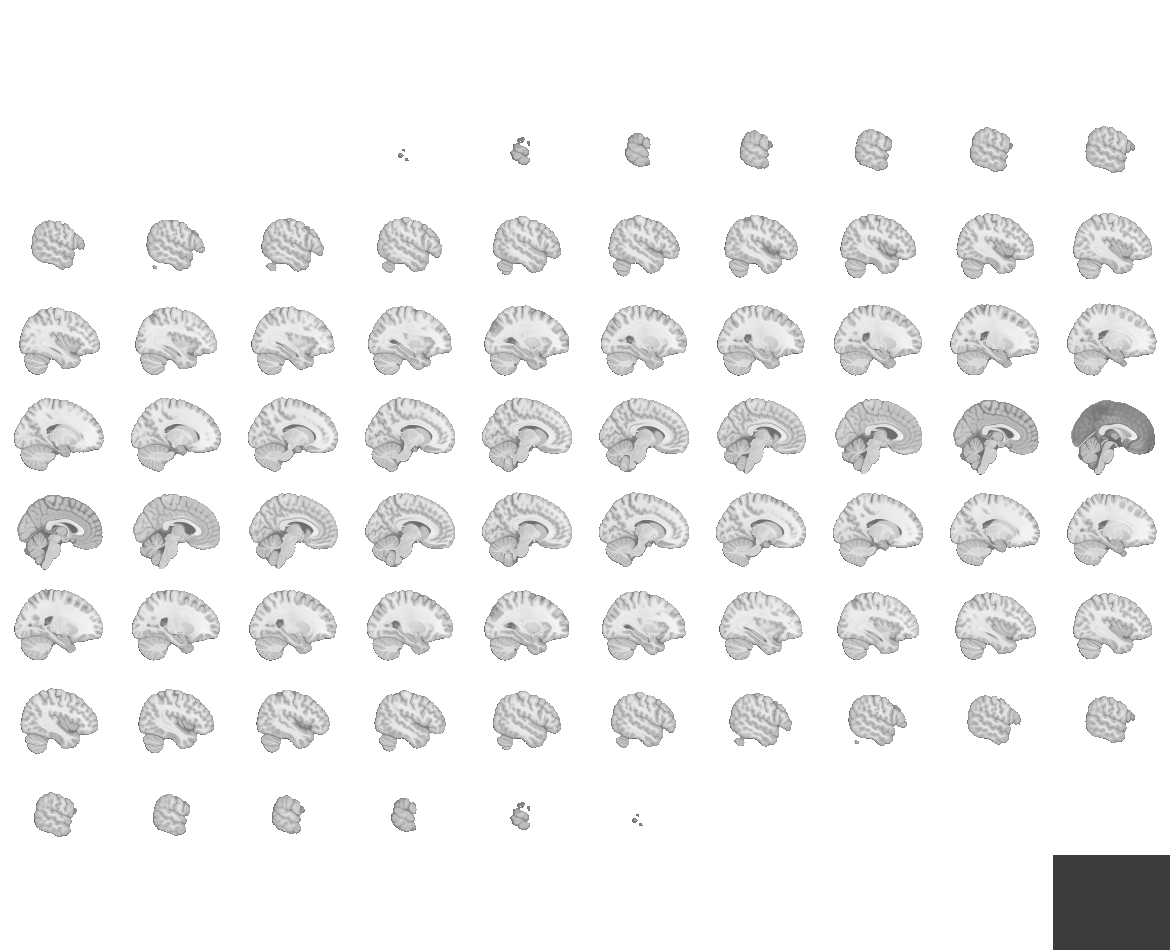
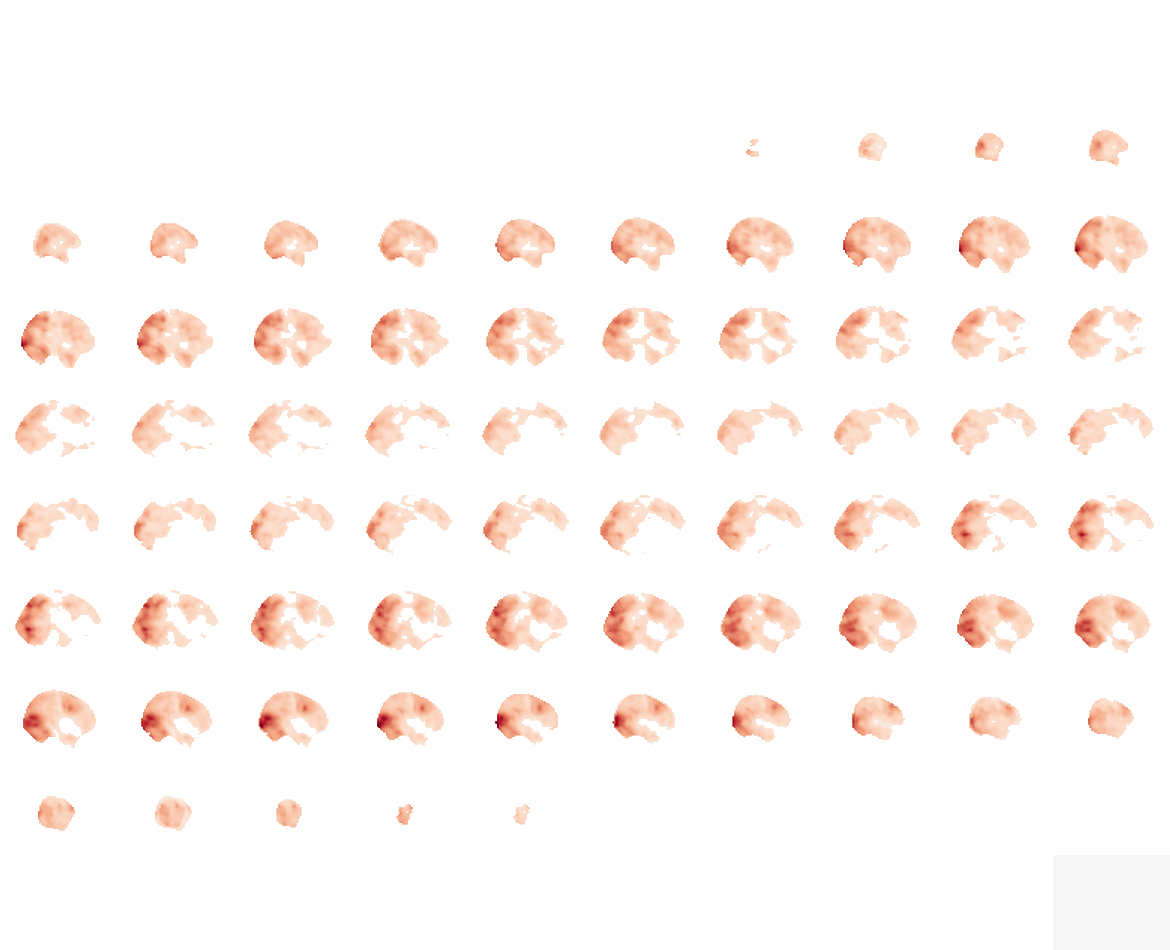


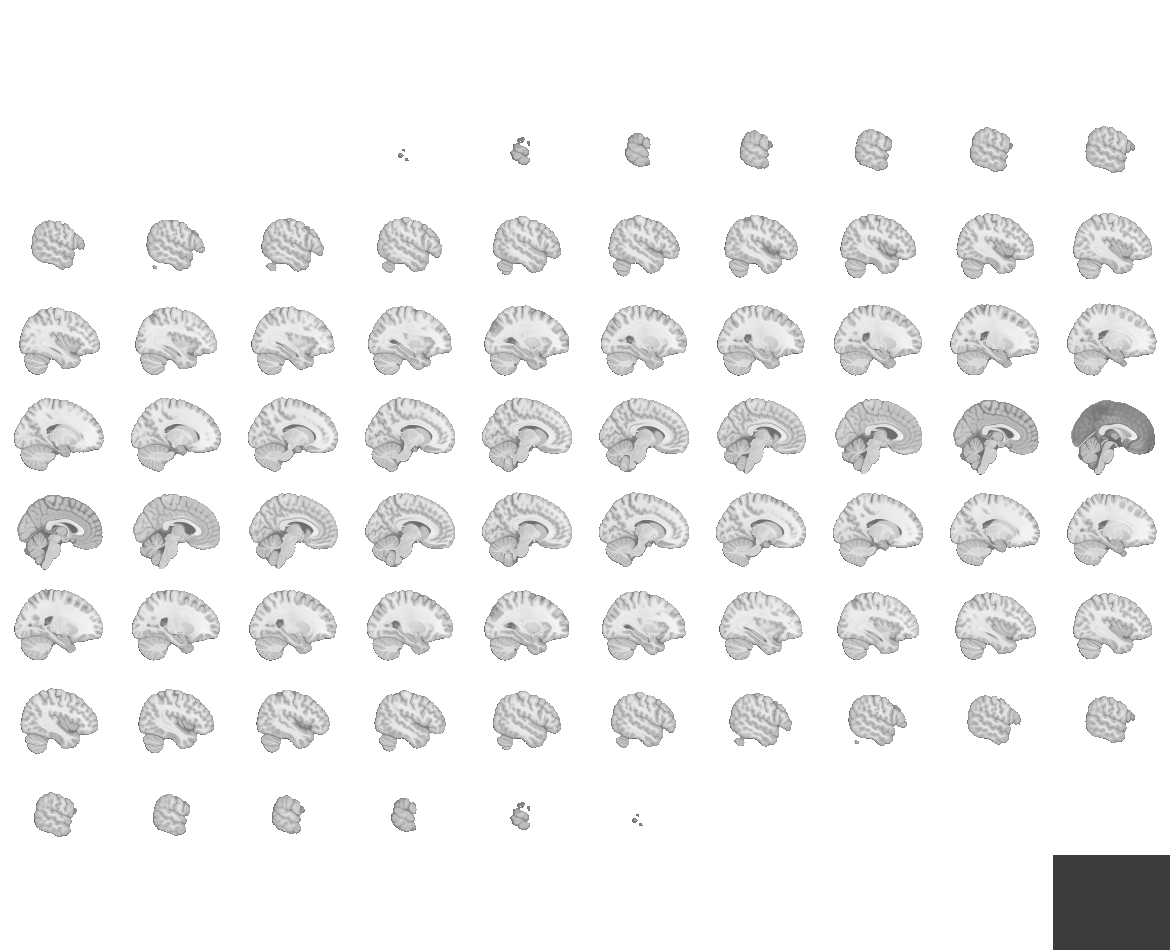
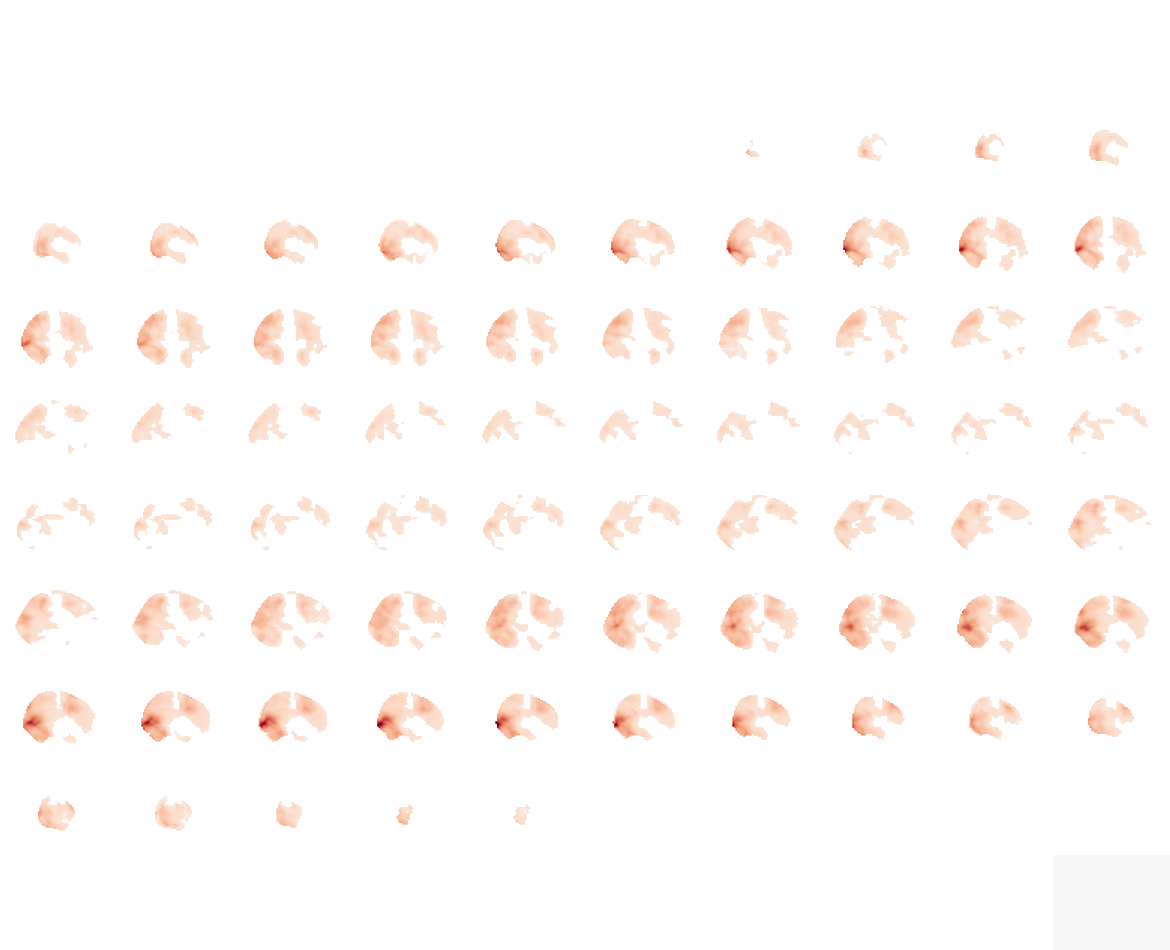

In [16]:
# Interactive glass brain views (FDR 0.001)
for model_name in tmaps:
    tmap = tmaps[model_name][0.001]
    view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,
                             title=f'{model_name} (FDR < 0.001)')
    display(view)

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_35784\2561000382.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


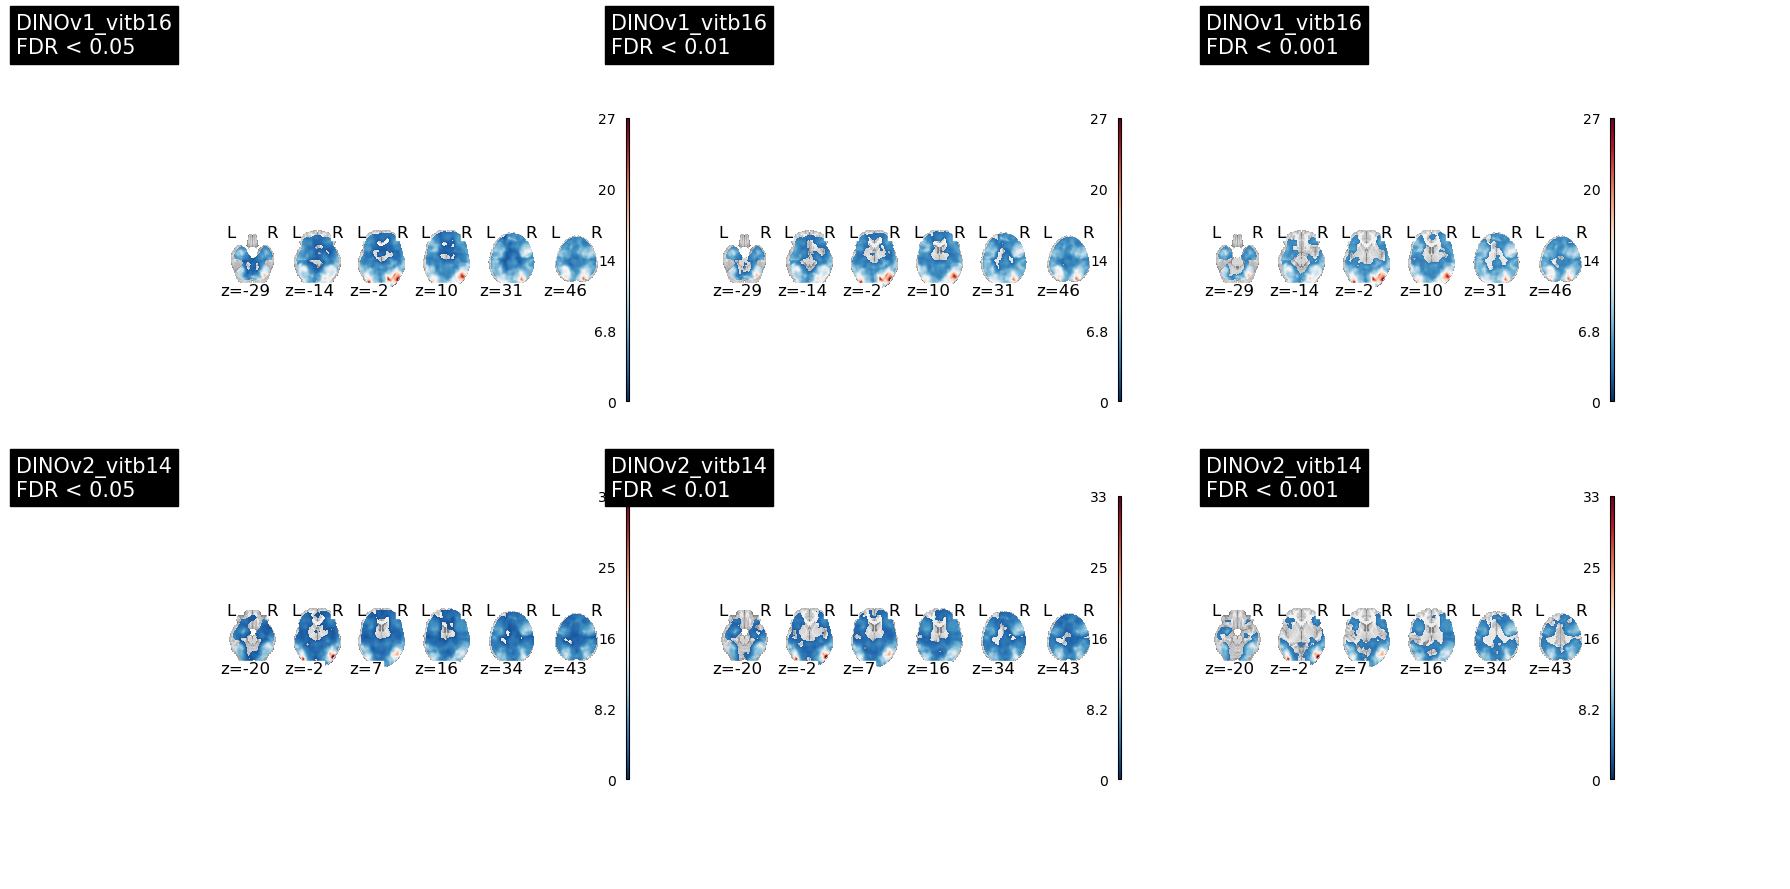

In [17]:
# Static slice views: rows = models, columns = FDR thresholds
model_names_list = list(tmaps.keys())
n_models = len(model_names_list)
n_fdrs = len(FDR_ALPHAS)

fig, axes = plt.subplots(n_models, n_fdrs, figsize=(6 * n_fdrs, 4.5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

for row, model_name in enumerate(model_names_list):
    for col, fdr_alpha in enumerate(FDR_ALPHAS):
        tmap = tmaps[model_name][fdr_alpha]
        plotting.plot_stat_map(
            tmap, display_mode='z', cut_coords=6,
            title=f'{model_name}\nFDR < {fdr_alpha}',
            axes=axes[row, col],
            threshold=0, colorbar=True
        )

plt.tight_layout()
plt.savefig('./outputs/tmap_DINO_v1v2_all_fdr.png', dpi=150)
plt.show()

## 9. Reload saved results (if restarting)

Uncomment and run if you already computed the searchlight and just want to reload.

In [18]:
# # Reload saved embeddings
# all_embeddings = {}
# for name in ['DINOv1_vitb16', 'DINOv2_vitb14']:
#     all_embeddings[name] = np.load(f'./outputs/embeddings/{name}_embeddings.npy')
#     print(f'Loaded {name}: {all_embeddings[name].shape}')
#
# # Rebuild RDMs
# rdms = {name: rdm_from_features(emb, metric='correlation')
#         for name, emb in all_embeddings.items()}
#
# # Reload searchlight scores
# results = {}
# for name in rdms:
#     eval_scores = np.load(f'./outputs/20sub_SL_eval_{name}.npy')
#     print(f'Reloaded {name}: {eval_scores.shape}')
#     results[name] = {'eval_scores': eval_scores, 'voxel_ids': None}
#
# # NOTE: if voxel_ids is None, recompute searchlight centers:
# # centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)
# # Then run one dummy subject to get voxel_ids from SL_RDM.rdm_descriptors